# Run a case

Runs `case.yaml` in this folder with `coupling.py` (same as double-clicking `Run.cmd`),
then shows the summary and plots the saved profiles.

Edit the settings in `case.yaml` (or build one with `case_builder.html`), then
**Restart Kernel and Run All Cells**. To run another case file, change `CASE_FILE` below.

In [1]:
import sys
from pathlib import Path
import yaml

CASE_FILE = Path("case.yaml")          # path relative to this notebook

case = yaml.safe_load(CASE_FILE.read_text(encoding="utf-8"))
results = (CASE_FILE.parent / case["output"]["folder"]).resolve()
print(CASE_FILE.read_text(encoding="utf-8"))

# One input file, four sections matching the four Python files.
# Run in the WSL fenicsx environment: python coupling.py case.yaml

# 1. chemistry.py: GEMS project, chemical conditions, and recipes.
chemistry:
  project: chemistry_data/b_time0-dat.lst
  temperature: 298.15                  # K
  pressure: 100000                     # Pa
  aqueous_phase: aq_gen
  solid_phases: [CSHQ, Portlandite, Silica-amorph]

  # Example-specific Gibbs energy adjustments (J/mol), applied in memory.
  # Copied from GEMS_ADE_1D_Template/cement.py; not universal constants.
  gibbs: {H2O@: -237183.0, Ca+2: -552400.0}

  # Initial element amounts: mol per 1 dm3 BULK, including water and solids.
  initial:
    Ca: 1.119218076064
    Si: 0.31000148638994
    H: 58.52226105076
    O: 31.00037832923
    Cl: 1.0e-15

  # Inlet element amounts: mol per recipe. GEMS supplies its aqueous volume.
  inlet:
    Ca: 0.01460
    Cl: 0.02919801532501
    H: 111.0167489181
    O: 55.508741415148
    Si: 0.000183

# 2. t

## Run

In [2]:
!{sys.executable} coupling.py "{CASE_FILE}"

[2026-09-24 15:54:08.255] [gems3k] [info] Home directory is /home/xi_b
step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=7.105e-12 mol/m3, water mismatch=0.25%
step=5, time=1.57788e+07 s, balance=1.805e-13 mol/m2, chemistry=7.887e-10 mol/m3, water mismatch=0.25%
step=10, time=3.15576e+07 s, balance=2.270e-13 mol/m2, chemistry=4.476e-10 mol/m3, water mismatch=0.25%
step=15, time=4.73364e+07 s, balance=2.270e-13 mol/m2, chemistry=5.542e-09 mol/m3, water mismatch=0.25%
step=20, time=6.31152e+07 s, balance=2.270e-13 mol/m2, chemistry=3.510e-09 mol/m3, water mismatch=0.25%
Saved: /mnt/c/Users/xi_b/3D Objects/suduko/GEMS-FENICSX/FEniCSx_GEMS_Beginner/results/current


## Summary

`summary.txt` is `COMPLETED` or `FAILED`; on failure the traceback is also in `failure.txt`.

COMPLETED
Mode: coupled
Cells/states: 40; reference length: 0.004 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 63115200.0 s; steps: 20
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 2.269851e-13 mol/m2
Maximum chemical element reconstruction error: 5.542233e-09 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.253730%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 0.499999814 to 0.504145456
Final De range: 4.99999629e-15 to 5.08325282e-15 m2/s
Porosity feedback: True
Diffusivity feedback: True
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



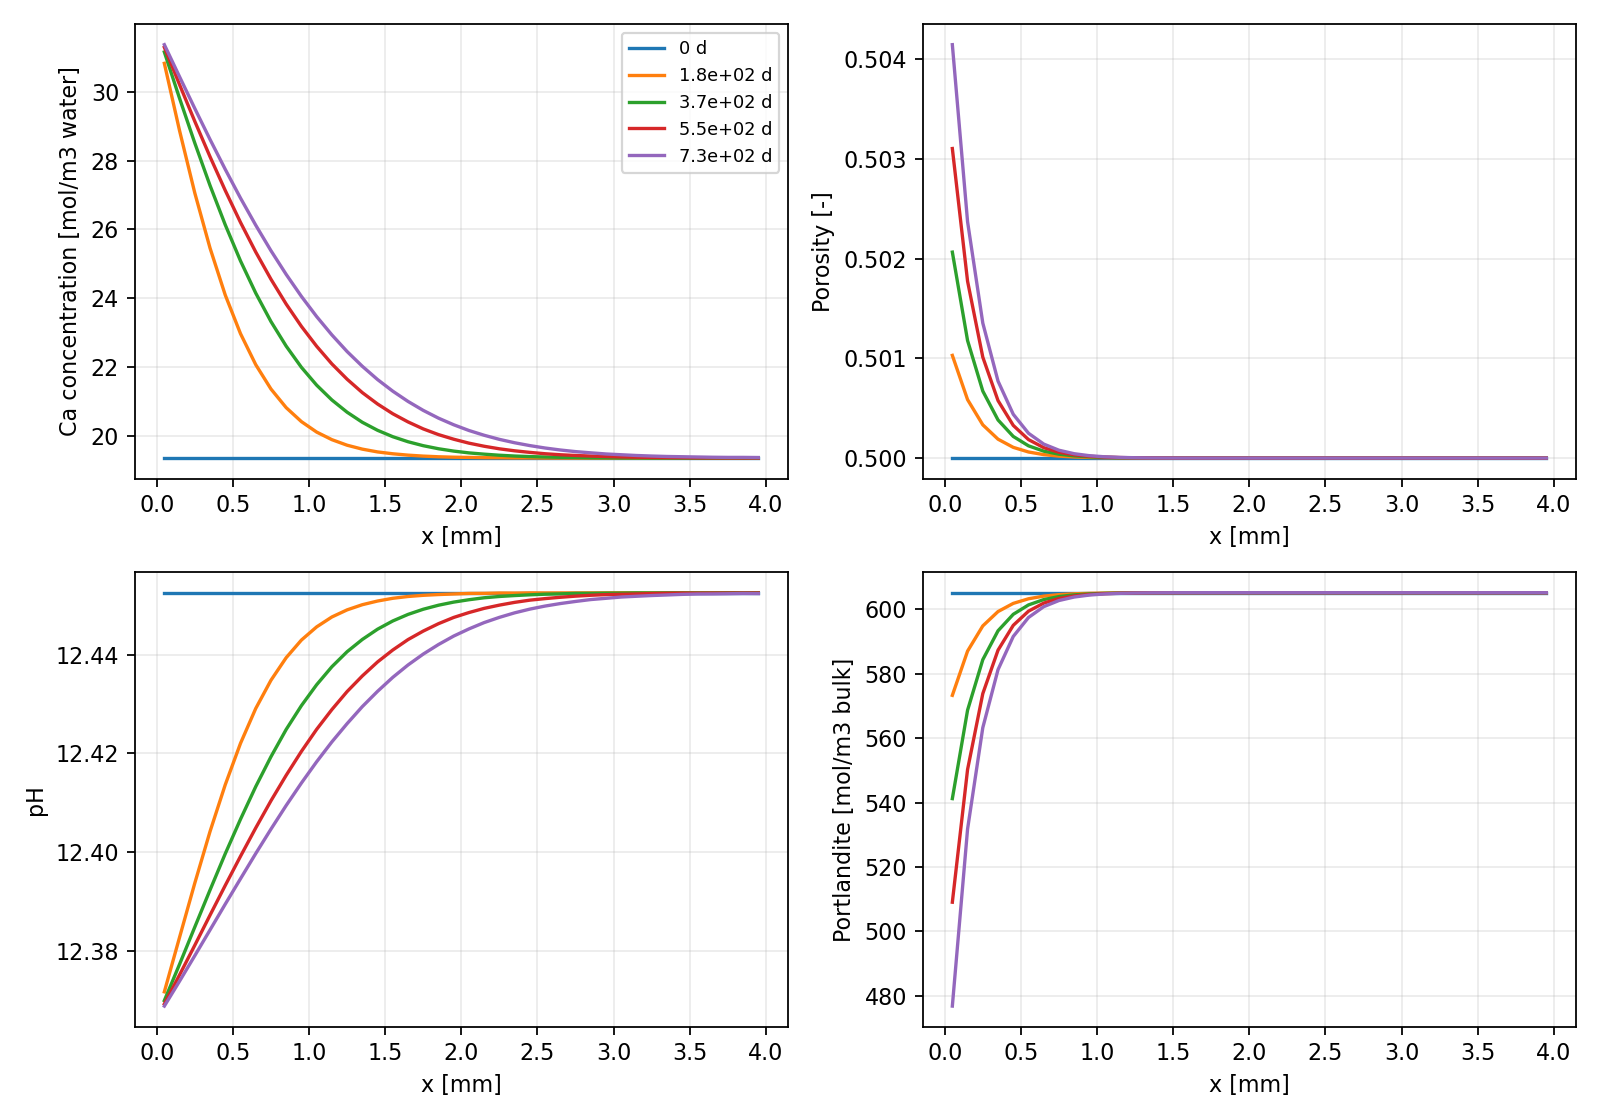

In [4]:
from IPython.display import Image, display
print((results / "summary.txt").read_text())
if (results / "profiles.png").exists():
    display(Image(filename=str(results / "profiles.png")))

## Profiles

One line per saved time (`output.every`). Dissolved concentrations are mol per m³ of pore
water; minerals are mol per m³ of bulk. Charge `Zz` is not shown.

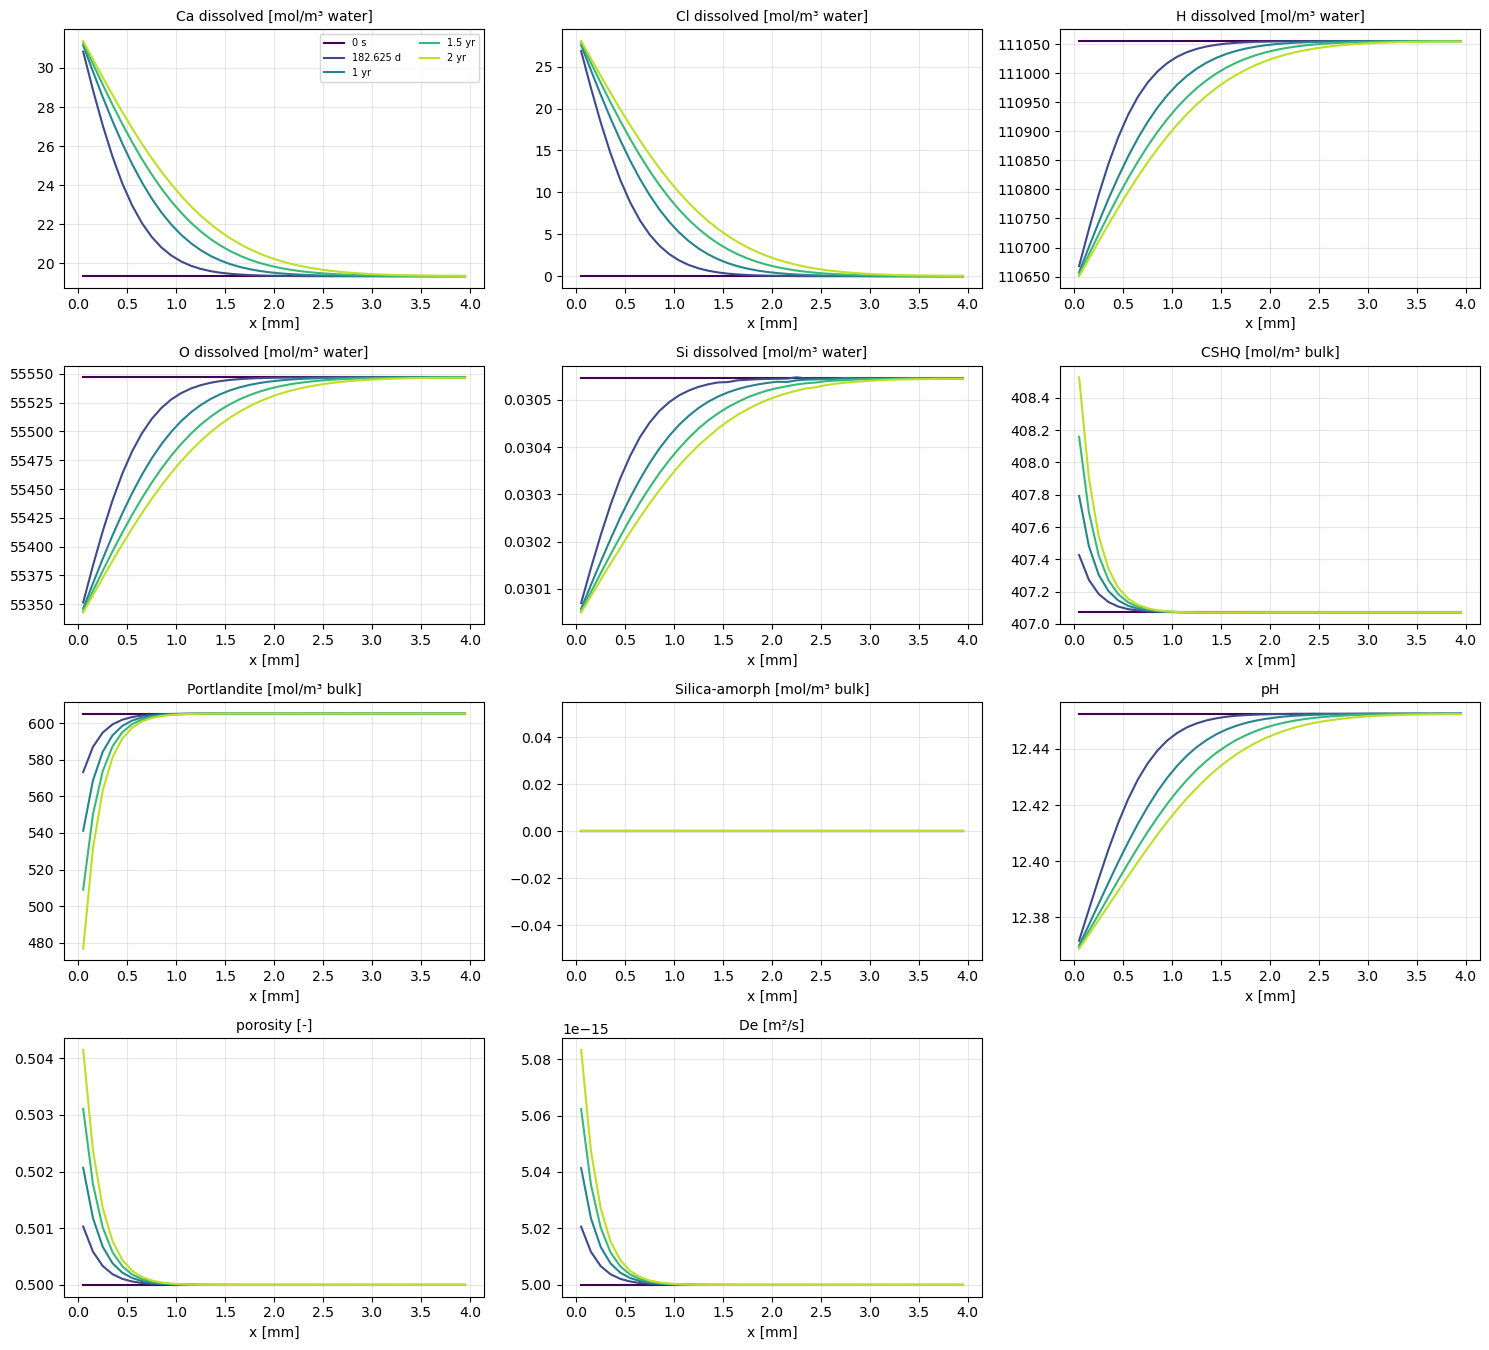

In [5]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt

p = pd.read_csv(results / "profiles.csv")
elements = [c[:-len("_c_mol_m3_water")] for c in p.columns
            if c.endswith("_c_mol_m3_water") and not c.startswith("Zz")]
minerals = [c[:-len("_mol_m3_bulk")] for c in p.columns
            if c.endswith("_mol_m3_bulk") and not c.endswith("_total_mol_m3_bulk")]
panels = ([(f"{e}_c_mol_m3_water", f"{e} dissolved [mol/m³ water]") for e in elements]
          + [(f"{m}_mol_m3_bulk", f"{m} [mol/m³ bulk]") for m in minerals]
          + [("pH", "pH"), ("phi", "porosity [-]"), ("De_m2_s", "De [m²/s]")])

times = sorted(p["time_s"].unique())
day, year = 86400.0, 365.25 * 86400.0
def label(t):
    return f"{t / year:g} yr" if t >= year else f"{t / day:g} d" if t >= day else f"{t:g} s"

ncols = 3
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()
colors = plt.cm.viridis(np.linspace(0, 0.9, len(times)))
for ax, (col, title) in zip(axes, panels):
    for t, color in zip(times, colors):
        g = p[p["time_s"] == t].sort_values("x_m")
        ax.plot(g["x_m"] * 1e3, g[col], color=color, label=label(t))
    ax.set_title(title, fontsize=10); ax.set_xlabel("x [mm]"); ax.grid(alpha=0.3)
for ax in axes[len(panels):]:
    ax.axis("off")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## Mass balance

Column inventory minus the initial inventory must equal what crossed the boundaries.
`balance_error` should stay near round-off; `chemistry_error` is the GEMS element
reconstruction error of the step.

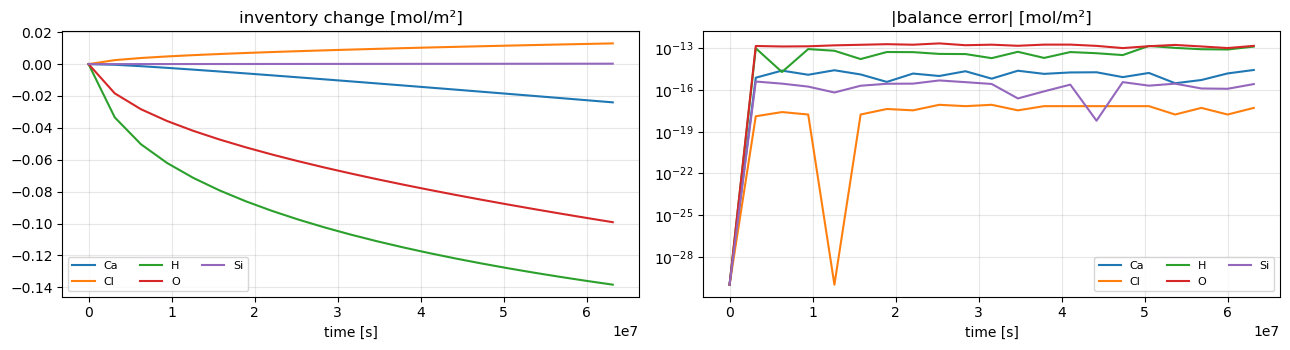

max chemistry error [mol/m3]: 5.542233338928781e-09


In [6]:
mb = pd.read_csv(results / "mass_balance.csv")
mb = mb[mb["component"] != "Zz"]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for name, g in mb.groupby("component"):
    axes[0].plot(g["time_s"], g["inventory_mol_m2"] - g["inventory_mol_m2"].iloc[0], label=name)
    axes[1].semilogy(g["time_s"], g["balance_error_mol_m2"].abs() + 1e-30, label=name)
axes[0].set(title="inventory change [mol/m²]", xlabel="time [s]")
axes[1].set(title="|balance error| [mol/m²]", xlabel="time [s]")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()
print("max chemistry error [mol/m3]:", mb["chemistry_error_mol_m3"].max())